<a href="https://colab.research.google.com/github/harjasjolly-create/trading-suggestion-project/blob/main/hypothesis_verifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import yfinance as yf
import pandas as pd
data = yf.download("AAPL", period="54wk", interval="1wk")
import seaborn as sns

/tmp/ipykernel_4535/2807584764.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", period="54wk", interval="1wk")
[*********************100%***********************]  1 of 1 completed


In [4]:
df=pd.DataFrame(data)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 55 entries, 2025-07-28 to 2026-08-10
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   55 non-null     float64
 1   (High, AAPL)    55 non-null     float64
 2   (Low, AAPL)     55 non-null     float64
 3   (Open, AAPL)    55 non-null     float64
 4   (Volume, AAPL)  55 non-null     int64  
dtypes: float64(4), int64(1)
memory usage: 2.6 KB


**BUILDING CHART_ANALYSIS MODEL **

In [5]:
close,high,low,open,volume=df.iloc[:,0],df.iloc[:,1],df.iloc[:,2],df.iloc[:,3],df.iloc[:,4]


**creating simple moving average(sma)** somewhat an average position vector but of closing prices(average closing value fo a batch

In [6]:
sma=close.rolling(window=20).mean()#taking batch of 20 weeks at a time, shifting by 1
sma


,Close
,AAPL
Date,
2025-07-28,NaN
2025-08-04,NaN
2025-08-11,NaN
2025-08-18,NaN
2025-08-25,NaN
2025-09-01,NaN
2025-09-08,NaN
2025-09-15,NaN


[Text(0.5, 0, 'Time'), Text(0, 0.5, 'SMA')]

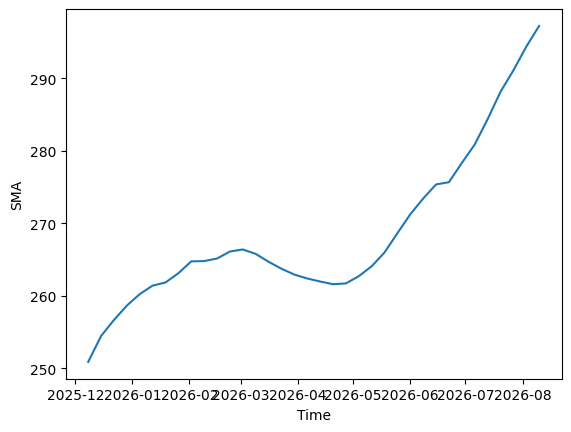

In [7]:
#visualizing sma
sns.lineplot(sma.dropna()).set(xlabel='Time',ylabel='SMA')

**creating average true range(14 candle) (ATR14)**

In [8]:
from os import name
tr1=high-low
#now we need prev timeframe's close value
close_prev=close.shift(1)#since we need prev week closing
tr2=(high-close_prev).abs()
tr3=(low-close_prev).abs()
values=pd.concat([tr1,tr2,tr3],axis=1)
tr_final=values.max(axis=1)
atr14=tr_final.rolling(window=14).mean()
atr14.rename('ATR14',inplace=True)

atr14#so basically average max volatility over 14cweeks batches

,ATR14
Date,
2025-07-28,NaN
2025-08-04,NaN
2025-08-11,NaN
2025-08-18,NaN
2025-08-25,NaN
2025-09-01,NaN
2025-09-08,NaN
2025-09-15,NaN
2025-09-22,NaN


**EMA**

Building ema so as to incorporate recent trends more weighted than past trends , for better accuracy, ill be using ema20 and ema50 with assumption that ema20 moving faaster than ema 50 means bullish trend

In [9]:
ema20=close.ewm(span=20,adjust=False).mean()
ema50=close.ewm(span=50,adjust=False).mean()#weight decreases as day goes more in past
ema_signal=(ema20-ema50)/close#dividing by closing price so as to create a ratio relative to stock price for better classification model training across different stocks
ema_signal

,Close
,AAPL
Date,
2025-07-28,0.000000
2025-08-04,0.006588
2025-08-11,0.012762
2025-08-18,0.017506
2025-08-25,0.022032
2025-09-01,0.027111
2025-09-08,0.031453
2025-09-15,0.035543


[Text(0.5, 0, 'Time'), Text(0, 0.5, 'EMA')]

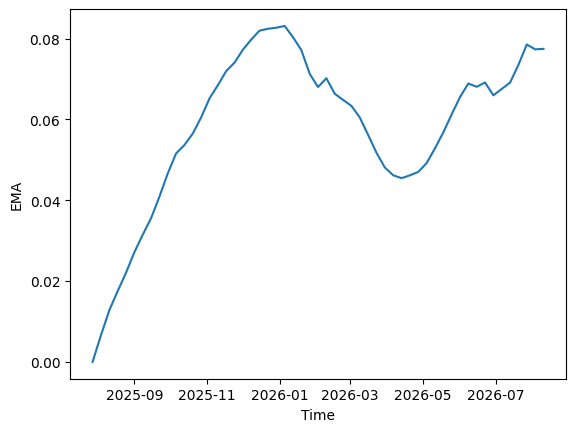

In [10]:
sns.lineplot(ema_signal).set(xlabel='Time',ylabel='EMA')

**Building RSI i.e relative strength of buyers to sellers**, cosidering rsi>50 as bullish,<50 as bearish ,>70 as overbought,<30 as oversold , basically it tells what poercentage of price movements is bullish

[Text(0.5, 0, 'Time'), Text(0, 0.5, 'RSI')]

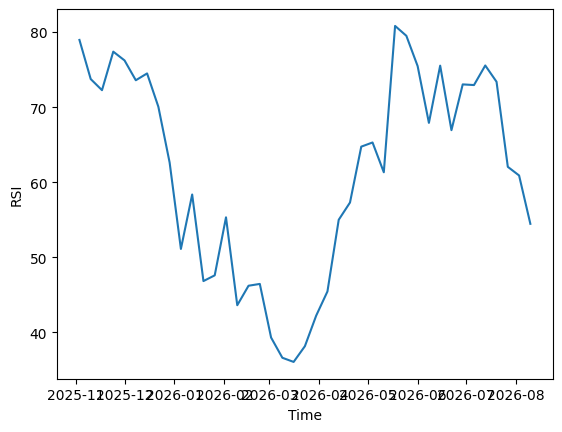

In [11]:
delta=close.diff()# calculating price change
gain=delta.clip(lower=0).rolling(14).mean()
loss=-delta.clip(upper=0).rolling(14).mean()
rs=gain/loss
#normalising rs from 0 ro 100 instead of 0 to infinity
rsi=100-100/(1+rs)
sns.lineplot(rsi).set(xlabel='Time',ylabel='RSI')

note: each rolling code requires actual entires so initial and final value might be considered nan output, as im currently using 54 week data, we can increase it to create a better model

**Building support resistance levels**

firstly, building swing highs and swing lows thats local highs and lows over 7 week windows

In [12]:
df["is_swing_high"]=(high==high.rolling(7,center=True).max())
df["is_swing_low"]=(low==low.rolling(7,center=True).min())
swing_high=df.loc[df['is_swing_high'],('High','AAPL')]
swing_low=df.loc[df["is_swing_low"],('Low','AAPL')]


now, we need to cluster swing highs and lows that are almost nearby so as to create the support and resistance levels but the zone width to consider two lows in same cluster is dependent on the volatility of stock  so well use atr for this ans assume a safe zone width of atr*0.5 so the lows can be within 50% of volatility at that time and hence considered the same lows and if 2 lows fall into a cluster, then that will be the support

In [13]:
atr_multiplier=0.5

In [14]:
support_df=pd.concat([swing_low,atr14],axis=1).dropna()
support_df


,"(Low, AAPL)",ATR14
Date,,
2026-01-19,242.759215,10.319516
2026-03-30,245.072652,13.001510
2026-06-22,273.514106,15.877309


In [15]:
#converting to list of dictionaries so that i can pop without any index error and also itll increase speed as dataframes are slow in delecting rows and looping over them (though they are fast at simukltaneous math)
swinglows=support_df.to_dict('records')#using record so that it created dictionary liost row wise and not column wise(record and row are same things)
swinglows


[{('Low', 'AAPL'): 242.75921493368202, 'ATR14': 10.31951580409614},
 {('Low', 'AAPL'): 245.07265167866177, 'ATR14': 13.001509704514573},
 {('Low', 'AAPL'): 273.51410564235374, 'ATR14': 15.877309275574545}]

In [16]:
true_support=[]
while len(swinglows)>0:
  base_item = swinglows.pop(0)
  base_price = base_item[('Low', 'AAPL')]
  base_atr = base_item['ATR14']
  zone_width=atr_multiplier*base_atr
  potential_support=[base_price]
  remaining=[]
  for rest in swinglows:
    if abs(rest[('Low', 'AAPL')]-base_price)<=zone_width:
      potential_support.append(rest[('Low', 'AAPL')])
    else:
      remaining.append(rest)
  swinglows=remaining
  if len(potential_support)>=2:
    avg_support=sum(potential_support)/len(potential_support)
    true_support.append(avg_support)


In [17]:
true_support

[243.9159333061719]

In [18]:
#now coding true_resistance

In [19]:
resistance_df=pd.concat([swing_high,atr14],axis=1).dropna()
resistance_df

,"(High, AAPL)",ATR14
Date,,
2025-10-27,276.299373,12.819296
2025-12-01,287.836509,11.305386
2026-02-02,280.147425,10.899126
2026-06-08,317.126504,14.625509


In [20]:
swinghighs=resistance_df.to_dict('records')
true_resistance=[]
while len(swinghighs)>0:
  top_item = swinghighs.pop(0)
  top_price = top_item[('High', 'AAPL')]
  top_atr = top_item['ATR14']
  zone_width=atr_multiplier*top_atr
  potential_resistance=[top_price]
  remaining=[]
  for rest in swinghighs:
    if abs(rest[('High', 'AAPL')]-top_price)<=zone_width:
      potential_resistance.append(rest[('High', 'AAPL')])
    else:
      remaining.append(rest)
  swinghighs=remaining
  if len(potential_resistance)>=2:

    avg_resistance=sum(potential_resistance)/len(potential_resistance)
    true_resistance.append(avg_resistance)




In [21]:
true_resistance

[278.223398756993]

**finding y for further modelling**

In [22]:
# ill be using triple barrier method for stock_execution score and alpha for stock_alpha score so as to check strength relative to benchmark
#ill use s&p 500 returns as benchmark


**triple barrier**

In [32]:

stock_data=pd.concat([close,atr14],axis=1)
#using name upper amnd lower barrier instead of target and stop loss so as to justify the name triple barrier;)

In [35]:
stock_data['upper_barrier']=stock_data[('Close', 'AAPL')]+stock_data['ATR14']*2
stock_data['lower_barrier']=stock_data[('Close', 'AAPL')]-stock_data['ATR14']*1
stock_data.sample(5)

,"(Close, AAPL)",ATR14,upper_barrier,lower_barrier
Date,,,,
2025-08-18,226.921753,NaN,NaN,NaN
2025-11-24,278.093048,11.036943,300.166934,267.056105
2025-11-10,271.670502,11.043420,293.757342,260.627082
2026-04-20,270.577118,13.785072,298.147261,256.792046
2026-07-27,308.643829,20.161275,348.966379,288.482554


In [91]:
#lets use time barrier of 2 weeks
stock_data["shifted_close"]=stock_data[('Close', 'AAPL')].shift(-2)


In [101]:
#now giving score of +1,-1 and 0 accordingly
import numpy as np
conditions=[(stock_data["shifted_close"]>=stock_data['upper_barrier']),(stock_data["shifted_close"]<=stock_data['lower_barrier'])]
choices=[1,-1]
stock_data["exec_score"]=np.select(conditions,choices,default=0)
stock_data.sample(5)


,"(Close, AAPL)",ATR14,upper_barrier,lower_barrier,exec_score,shifted_close
Date,,,,,,
2026-05-25,311.791107,13.442002,338.675111,298.349105,-1,290.879150
2026-02-23,263.709381,12.522064,288.753509,251.187317,-1,249.674438
2026-06-22,283.535461,15.877309,315.290080,267.658152,0,315.048309
2025-10-20,261.852722,NaN,NaN,NaN,0,267.481903
2026-03-02,257.001343,12.713783,282.428909,244.287560,0,247.548233


**now the benchmark comparison that is alpha score**

In [107]:
snp_data=yf.download("^GSPC",period="54wk",interval="1wk")
snp_close=pd.DataFrame(snp_data).iloc[:,0]
snp_close.info()

/tmp/ipykernel_4535/520086488.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  snp_data=yf.download("^GSPC",period="54wk",interval="1wk")
[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.series.Series'>
DatetimeIndex: 55 entries, 2025-07-28 to 2026-08-10
Series name: ('Close', '^GSPC')
Non-Null Count  Dtype  
--------------  -----  
55 non-null     float64
dtypes: float64(1)
memory usage: 880.0 bytes


In [115]:
#now comparison
#ill be using 2 week timeframe for return comparison
stock_data['stock_return_2wk']=(stock_data['shifted_close']-stock_data[('Close', 'AAPL')])/stock_data[('Close', 'AAPL')]
snp_data['shifted_close']=snp_close.shift(-2)
stock_data['snp_return_2wk']=(snp_data['shifted_close']-snp_data[('Close', '^GSPC')])/snp_data[('Close', '^GSPC')]
stock_data['aplha']=stock_data['stock_return_2wk']-stock_data['snp_return_2wk']
#considering a buffer oif 0.5% so as to remove buffer as if alpha is 0.2% more than benchmark, it isnt really a great winner but similiar to 0 so just a noise so well consider it as 0
conditions=[(stock_data['aplha']>0.005),stock_data['aplha']<0.005]
choices=[1,-1]
stock_data["alpha_score"]=np.select(conditions,choices,default=0)
stock_data['alpha_score'].head()

,alpha_score
Date,
2025-07-28,1
2025-08-04,-1
2025-08-11,-1
2025-08-18,1
2025-08-25,-1


**now creating a score based on support resitance , considering if close is within 1%of nearest support or resistance, then well consider the actual +-1 score else iot wopnt really matter and hence 0**


In [120]:
#true_support
#true_resistance
#finding closest resistance and support
def find_nearest_support(value):
  min_dist=(abs(true_support[0]-value))
  nearest_support=true_support[0]
  for i in true_support:
    if abs(i-value)<=min_dist:
      min_dist=abs(i-value)
      nearest_support=i
  return nearest_support
def find_nearest_resistance(value):
  min_dist=(abs(true_resistance[0]-value))
  nearest_resistance=true_resistance[0]
  for i in true_resistance:
    if abs(i-value)<=min_dist:
      min_dist=abs(i-value)
      nearest_resistance=i
  return nearest_resistance
stock_data["nearest resistance"]=0
stock_data["nearest support"]=0
stock_data["nearest resistance"]=stock_data[('Close', 'AAPL')].apply(find_nearest_resistance)
stock_data["nearest support"]=stock_data[('Close', 'AAPL')].apply(find_nearest_support)





In [141]:
#now if stock is in 1% zone of nearest support that would mean upside potential so floor_ceiling_score=+1 and -1 for similar with nearest resistance else 0
conditions=[(abs(stock_data[('Close', 'AAPL')]-stock_data['nearest support'])/stock_data['nearest support']<=0.01),(abs(stock_data[('Close', 'AAPL')]-stock_data['nearest resistance'])/stock_data['nearest resistance']<=0.01)]
choices=[+1,-1]
stock_data['floor_ceiling_score']=np.select(conditions,choices,default=0)
stock_data['floor_ceiling_score'].sample(5)


,floor_ceiling_score
Date,
2026-02-02,-1
2026-06-15,0
2026-01-26,0
2026-02-16,0
2026-04-27,-1


** now scraping some company ratios from macrotrends**

In [170]:
import requests
from bs4 import BeautifulSoup
headers={'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
web=requests.get('https://stockanalysis.com/stocks/aapl/financials/ratios/$0',headers=headers).text
web

'<!doctype html>\n<html lang="en">\n\t<head>\n\t\t<meta charset="utf-8" />\n\t\t<meta name="viewport" content="width=device-width, initial-scale=1" />\n\t\t\n\t\t<link href="/_app/immutable/assets/0.DkiBmviK.css" rel="stylesheet">\n\t\t<link href="/_app/immutable/assets/_TrustBlock.DX2EOQbN.css" rel="stylesheet">\n\t\t<link href="/_app/immutable/assets/_FinancialsLayout.Da5KOgCM.css" rel="stylesheet"><!--[--><!--[--><script async src="https://securepubads.g.doubleclick.net/tag/js/gpt.js"></script> <script>\n\t\t\tInvestingChannelQueue = window.InvestingChannelQueue || []\n\t\t</script> <script async src="https://u5.investingchannel.com/static/uat.js"></script><!--]--><!--]--><!--[--><!--[--><meta name="description" content="Financial ratios for Apple (AAPL). Includes annual, quarterly and trailing numbers with history and charts."/><!--]--> <!--[!--><!--]--> <link rel="canonical" href="https://stockanalysis.com/stocks/aapl/financials/ratios/"/> <!--[!--><!--]--> <!--[!--><!--]--> <meta

In [172]:
response=BeautifulSoup(web,'lxml')
data_=response.find_all('td',class_="svelte-tnz7cg")
for i in data_:
  print(i.text)


 Market Capitalization  
4,464,797
3,791,126
3,463,350
2,676,737
2,417,523
2,428,612
Market Cap Growth   
28.94%
9.46%
29.39%
10.72%
-0.46%
26.47%
 Enterprise Value    
4,402,624
3,759,838
3,411,613
2,619,474
2,357,906
2,370,459
 Last Close Price    
305.93
254.52
225.90
168.93
147.55
143.30
 PE Ratio    
35.10
33.85
36.95
27.60
24.22
25.65
 Forward PE    
33.42
32.97
31.48
26.72
24.27
26.67
 PS Ratio    
9.56
9.11
8.86
6.98
6.13
6.64
 PB Ratio    
41.57
51.42
60.81
43.07
47.71
38.49
 P/TBV Ratio    
51.21
51.42
60.81
43.07
47.71
38.49
 P/FCF Ratio    
32.67
38.39
31.83
26.88
21.69
26.13
 P/OCF Ratio    
30.43
34.01
29.29
24.21
19.79
23.34
 PEG Ratio    
3.07
3.27
3.65
2.56
2.09
1.76
 EV/Sales Ratio    
9.43
9.04
8.73
6.83
5.98
6.48
 EV/EBITDA Ratio    
26.21
25.98
25.34
20.82
18.06
19.72
 EV/EBIT Ratio    
28.43
28.26
27.69
22.92
19.74
21.76
 EV/FCF Ratio    
32.21
38.07
31.36
26.30
21.16
25.50
 Debt / Equity Ratio    
0.78
1.52
2.09
1.99
2.61
2.16
 Debt / EBITDA Ratio    
0.45
0.69
0

above is all detail in batches of 6 because it gives data from year 2021 to 2026 , we only need 2026 data except for pe ratio as it depends on stock's sector like ai stocks tend to have higher pe so ill be using pe relative to avg pe rest only 2026 data

In [212]:
counter=0
titles=[]
for i in data_:
  if counter%7==0:#since they come at index0 then 7 and so on
    titles.append(i.text.strip()) # Striping whitesoace here as titles have some extra spaces at ends which i dont know how much
  counter+=1
titles

['Market Capitalization',
 'Market Cap Growth',
 'Enterprise Value',
 'Last Close Price',
 'PE Ratio',
 'Forward PE',
 'PS Ratio',
 'PB Ratio',
 'P/TBV Ratio',
 'P/FCF Ratio',
 'P/OCF Ratio',
 'PEG Ratio',
 'EV/Sales Ratio',
 'EV/EBITDA Ratio',
 'EV/EBIT Ratio',
 'EV/FCF Ratio',
 'Debt / Equity Ratio',
 'Debt / EBITDA Ratio',
 'Debt / FCF Ratio',
 'Net Debt / Equity Ratio',
 'Net Debt / EBITDA Ratio',
 'Net Debt / FCF Ratio',
 'Asset Turnover',
 'Inventory Turnover',
 'Quick Ratio',
 'Current Ratio',
 'Return on Equity (ROE)',
 'Return on Assets (ROA)',
 'Return on Invested Capital (ROIC)',
 'Return on Capital Employed (ROCE)',
 'Earnings Yield',
 'FCF Yield',
 'Dividend Yield',
 'Payout Ratio',
 'Buyback Yield / Dilution',
 'Total Shareholder Return']

In [213]:

counter=-1
values=[]
for i in data_:
  if counter%7==0:#since they come at index1 then 8 and so on
    values.append(i.text)
  counter+=1
values


['4,464,797',
 '28.94%',
 '4,402,624',
 '305.93',
 '35.10',
 '33.42',
 '9.56',
 '41.57',
 '51.21',
 '32.67',
 '30.43',
 '3.07',
 '9.43',
 '26.21',
 '28.43',
 '32.21',
 '0.78',
 '0.45',
 '0.62',
 '-0.58',
 '-0.37',
 '-0.45',
 '1.31',
 '28.17',
 '0.81',
 '1.00',
 '148.75%',
 '27.08%',
 '101.57%',
 '66.20%',
 '2.89%',
 '3.06%',
 '0.35%',
 '12.39%',
 '2.13%',
 '2.48%']

In [230]:
dictionary=dict(zip(titles,values))#just got to know that we can use zip ro form pairs index wise and then dict to form key bvakeu pairs
fundamentals_2026=pd.DataFrame(dictionary,index=['year 2026'])
fundamentals_2026

,Market Capitalization,Market Cap Growth,Enterprise Value,Last Close Price,PE Ratio,Forward PE,PS Ratio,PB Ratio,P/TBV Ratio,P/FCF Ratio,...,Return on Equity (ROE),Return on Assets (ROA),Return on Invested Capital (ROIC),Return on Capital Employed (ROCE),Earnings Yield,FCF Yield,Dividend Yield,Payout Ratio,Buyback Yield / Dilution,Total Shareholder Return
year 2026,"4,464,797",28.94%,"4,402,624",305.93,35.10,33.42,9.56,41.57,51.21,32.67,...,148.75%,27.08%,101.57%,66.20%,2.89%,3.06%,0.35%,12.39%,2.13%,2.48%


**pe score**

In [215]:

pe_index=0
for i in data_:
  if 'PE Ratio' in i.text:

    print((pe_index))
  else:
    pe_index+=1

28


so pe is at 28 index

In [216]:
pe_list=[]
for i in data_[29:35]:#6 year data
   pe_list.append(float(i.text))
avg_pe=np.mean(pe_list)
avg_pe
current_pe=float(data_[29].text)
if (current_pe-avg_pe)/avg_pe>=0.1:
  pe_score=1
elif (current_pe-avg_pe)/avg_pe<=-0.1:
  pe_score=-1
else:
  pe_score=0
pe_score



1

**now finding peg score**

In [222]:
peg_ratio=float(fundamentals_2026.loc['year 2026','PEG Ratio'])
if peg_ratio<1:
  peg_score=1
elif 1<peg_ratio<2:
  peg_score=0
else:
  peg_score=-1
#used standard threshold for peg overvalued or undervalued
print(peg_score)

-1


**roe score using standard roe>20% roe<10% criteria**

In [228]:
roe=float(fundamentals_2026.loc['year 2026','Return on Equity (ROE)'][0:len(fundamentals_2026.loc['year 2026','Return on Equity (ROE)'])-1])
roe

148.75

In [229]:
if roe>=20:
  roe_score=+1
elif roe<=10:
  roe_score=-1
else:
  roe_score=0
roe_score


1

**debt/equity score using d/e<0.5 as safe adn d/e>1.5 as unsafe and in between moderate**

In [233]:
de_ratio=float(fundamentals_2026.loc['year 2026','Debt / Equity Ratio'])
de_ratio

0.78

In [235]:
if de_ratio<=0.5:
  de_score=+1
elif de_ratio>=1.5:
  de_score=-1
else:
  de_score=0
de_score

0